# Бустинги и ансамблевые модели

Практическая работа объединяет две работы: обучение ансамблей scikit-learn на регрессионной задаче о стоимости калифорнийского жилья и обучение внешних бустингов (XGBoost и CatBoost) на классификационной задаче о наличии диабета. Сравнение проводится относительно базовых моделей из предыдущих работ – линейной регрессии и логистической регрессии – чтобы увидеть, какой прирост качества дают ансамбли на графах.

## Требования для сдачи лабораторной работы

1. Выбрать набор данных для обучения моделей регрессии или классификации.
2. Провести предварительную обработку данных.
3. Обучить одну-две модели из ансамблей scikit-learn.
4. Добиться адекватного качества и проанализировать результаты.
5. Сделать выводы по обучению методами scikit-learn.
6. Снова выбрать набор данных (или взять прежний) под классификацию.
7. Провести предварительную обработку.
8. Обучить один-два внешних бустинга или ансамбля.
9. Оптимизировать гиперпараметры моделей.
10. Сформулировать выводы после обучения на внешних библиотеках.
11. Дать общее заключение по работе.

## Библиотеки

In [1]:
import os
import time
import random
from typing import cast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV
)

from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## Константы

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Выбор темы и стиля для графиков MatPlotLib и plotly. Создание палитры для графиков.

In [3]:
plt.style.use('dark_background')
pio.templates.default = 'plotly_dark'

PALETTE = {
    'baseline': '#90A4AE',
    'tree': '#FFB74D',
    'rf': '#4FC3F7',
    'gb': '#FF7043',
    'xgb': '#81C784',
    'cat': '#BA68C8',
    'extra': '#E57373',
}

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Часть 1. Ансамбли scikit-learn на California Housing

Задача – предсказать медианную стоимость жилья в районе по восьми признакам района: уровню дохода, возрасту застройки, размеру жилья, населённости и географическим координатам. Данные уже прошли предобработку в работе по регрессии и сохранены в `california_housing_processed.csv`.

### 1.1. Выбор набора данных

Берётся обработанный датасет из предыдущей работы. Целевой признак `MedHouseVal` приведён к нормированной шкале (StandardScaler поверх PowerTransformer), поэтому метрики MAE и RMSE здесь выражены не в сотнях тысяч долларов, а в стандартных отклонениях — это сохраняет сопоставимость с линейной моделью из прошлой работы.

In [4]:
DATA_PATH = 'california_housing_processed.csv' # Ссылка на файл в папке «3. Regression models»
housing = pd.read_csv(DATA_PATH)
print('Размер таблицы:', housing.shape)
housing.head()

Размер таблицы: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.916290,0.975223,6.984127,1.023810,-1.618362,2.555556,37.88,-122.23,1.718078
1,1.909694,-0.566735,6.238137,0.971880,1.090062,2.109842,37.86,-122.22,1.262941
2,1.601978,1.757447,8.288136,1.073446,-1.139047,2.802260,37.85,-122.24,1.228314
3,1.035967,1.757447,5.817352,1.073059,-0.999677,2.547945,37.85,-122.25,1.168611
4,0.198026,1.757447,6.281853,1.081081,-0.984697,2.181467,37.85,-122.25,1.173649


In [5]:
stats = housing.describe().T.round(3)
stats

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,0.000,1.000,-3.803,-0.658,0.017,0.653,3.310
HouseAge,20640.0,-0.000,1.000,-2.530,-0.818,0.074,0.681,1.757
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,0.000,1.000,-4.604,-0.570,-0.034,0.552,7.475
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.0,-0.000,1.000,-3.781,-0.711,-0.011,0.690,1.917


### 1.2. Предварительная обработка

Пропусков в обработанном датасете нет, выбросы по плотности населения и среднему числу жильцов уже обработаны в работе по регрессии. Разбиение производится в тех же пропорциях и с тем же случайным состоянием, что и в работе по регрессии: 75% обучение, 25% валидация.

In [6]:
TARGET_REG = 'MedHouseVal'
FEATURES_REG = [c for c in housing.columns if c != TARGET_REG]

X_h = np.asarray(housing[FEATURES_REG])
y_h = np.asarray(housing[TARGET_REG])

idx_tr, idx_val = train_test_split(
    np.arange(len(housing)),
    test_size=0.25, random_state=RANDOM_STATE, shuffle=True,
)
X_h_tr, X_h_val = X_h[idx_tr], X_h[idx_val]
y_h_tr, y_h_val = y_h[idx_tr], y_h[idx_val]
print(f'Train: {X_h_tr.shape[0]} | Validation: {X_h_val.shape[0]}')

Train: 15480 | Validation: 5160


### 1.3. Первые результаты применения ансамблей

Используется функция `score_regression`, которая возвращает метрики MAE, RMSE, $R^2$, MAPE отдельно на обучении и валидации и время обучения в секундах.

In [7]:
def score_regression(name, model, X_tr, y_tr, X_val, y_val):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    pred_tr = model.predict(X_tr)
    pred_val = model.predict(X_val)
    return {
        'model': name,
        'MAE_train': mean_absolute_error(y_tr, pred_tr),
        'MAE_val': mean_absolute_error(y_val, pred_val),
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val)),
        'R2_train': r2_score(y_tr, pred_tr),
        'R2_val': r2_score(y_val, pred_val),
        'MAPE_val': mean_absolute_percentage_error(
            np.where(np.abs(y_val) < 1e-3, 1e-3, y_val), pred_val
        ),
        'fit_s': fit_time,
    }


In [8]:
rf_default = RandomForestRegressor(
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_default = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

results_default = pd.DataFrame([
    score_regression('RandomForest (default)', rf_default,
                     X_h_tr, y_h_tr, X_h_val, y_h_val),
    score_regression('GradientBoosting (default)', gb_default,
                     X_h_tr, y_h_tr, X_h_val, y_h_val),
]).round(3)
results_default

,model,MAE_train,MAE_val,RMSE_train,RMSE_val,R2_train,R2_val,MAPE_val,fit_s
0,RandomForest (default),0.105,0.283,0.154,0.413,0.976,0.831,1.459,0.797
1,GradientBoosting (default),0.314,0.329,0.425,0.452,0.819,0.797,1.690,1.909


Чтобы понимать, насколько ансамбли выигрывают у предыдущих работ, пригодятся численные ориентиры из работы по регрессии — линейная модель и одиночное решающее дерево, оба с теми же параметрами разбиения:

In [9]:
reference_reg = pd.DataFrame([
    {'model': 'LinearRegression',  'MAE_val': 0.530, 'RMSE_val': 0.736, 'R2_val': 0.591},
    {'model': 'Ridge + Poly2 + log','MAE_val': 0.450, 'RMSE_val': 0.667, 'R2_val': 0.663},
    {'model': 'DecisionTree GridSearch','MAE_val': 0.417, 'RMSE_val': 0.611, 'R2_val': 0.718},
])
reference_reg

,model,MAE_val,RMSE_val,R2_val
0,LinearRegression,0.530,0.736,0.591
1,Ridge + Poly2 + log,0.450,0.667,0.663
2,DecisionTree GridSearch,0.417,0.611,0.718


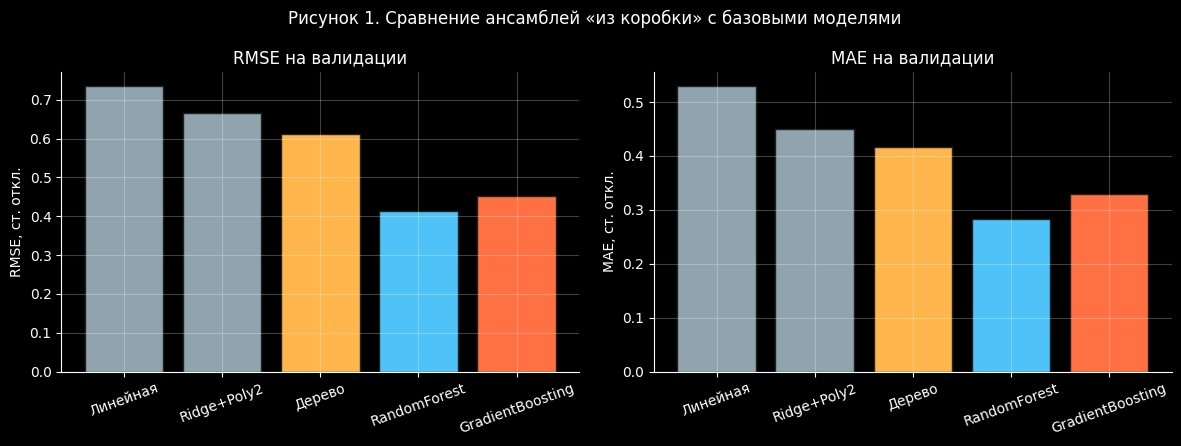

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

labels = [
    'Линейная',
    'Ridge+Poly2',
    'Дерево',
    'RandomForest',
    'GradientBoosting',
]
rmse_vals = [
    reference_reg.loc[0, 'RMSE_val'],
    reference_reg.loc[1, 'RMSE_val'],
    reference_reg.loc[2, 'RMSE_val'],
    results_default.loc[0, 'RMSE_val'],
    results_default.loc[1, 'RMSE_val'],
]
mae_vals = [
    reference_reg.loc[0, 'MAE_val'],
    reference_reg.loc[1, 'MAE_val'],
    reference_reg.loc[2, 'MAE_val'],
    results_default.loc[0, 'MAE_val'],
    results_default.loc[1, 'MAE_val'],
]
colors = [PALETTE['baseline'], PALETTE['baseline'], PALETTE['tree'],
          PALETTE['rf'], PALETTE['gb']]

ax[0].bar(labels, rmse_vals, color=colors, edgecolor='#212121')
ax[0].set_title('RMSE на валидации')
ax[0].set_ylabel('RMSE, ст. откл.')
ax[0].tick_params(axis='x', rotation=20)

ax[1].bar(labels, mae_vals, color=colors, edgecolor='#212121')
ax[1].set_title('MAE на валидации')
ax[1].set_ylabel('MAE, ст. откл.')
ax[1].tick_params(axis='x', rotation=20)

plt.suptitle('Рисунок 1. Сравнение ансамблей «из коробки» с базовыми моделями')
plt.tight_layout()
plt.show()

Даже без настройки гиперпараметров обе ансамблевые модели уже заметно опережают и линейную регрессию, и настроенное дерево из предыдущей работы: RMSE падает с 0.61 у дерева до примерно 0.41 у леса и 0.45 у бустинга. У случайного леса виден сильный перевес обучения над валидацией – это нормально для дефолтной конфигурации, подбор гиперпараметров и должен сгладить разрыв.

### 1.4. Оптимизация моделей

Для случайного леса использовался `RandomizedSearchCV` по числу деревьев, максимальной глубине и минимальному размеру листа: лес слабо чувствителен к точному значению этих параметров, поэтому случайного поиска по сетке с 12 итерациями достаточно. Для градиентного бустинга применялся `GridSearchCV` по числу итераций, глубине и скорости обучения — самые важные регуляторы качества у этого семейства.

In [11]:
rf_grid = {
    'n_estimators': [200, 400, 700],
    'max_depth': [None, 12, 20],
    'min_samples_leaf': [1, 5, 10],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid,
    n_iter=12,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
t0 = time.time()
rf_search.fit(X_h_tr, y_h_tr)
print(f'Поиск RF занял {time.time() - t0:.1f} c')
print('Лучшие параметры:', rf_search.best_params_)
print(f'Лучший CV RMSE: {-rf_search.best_score_:.3f}')
rf_best = cast(RandomForestRegressor, rf_search.best_estimator_)

/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/yambu/.pyenv/versions/3.14.3/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/yambu/.pyenv/versions/3.14.

Поиск RF занял 60.3 c
Лучшие параметры: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_depth': None}
Лучший CV RMSE: 0.421


In [12]:
gb_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
}
gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0,
)
t0 = time.time()
gb_search.fit(X_h_tr, y_h_tr)
print(f'Поиск GB занял {time.time() - t0:.1f} c')
print('Лучшие параметры:', gb_search.best_params_)
print(f'Лучший CV RMSE: {-gb_search.best_score_:.3f}')
gb_best = cast(GradientBoostingRegressor, gb_search.best_estimator_)

Поиск GB занял 37.1 c
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}
Лучший CV RMSE: 0.390


In [13]:
results_tuned = pd.DataFrame([
    score_regression('RandomForest (tuned)', rf_best,
                     X_h_tr, y_h_tr, X_h_val, y_h_val),
    score_regression('GradientBoosting (tuned)', gb_best,
                     X_h_tr, y_h_tr, X_h_val, y_h_val),
]).round(3)
results_tuned

,model,MAE_train,MAE_val,RMSE_train,RMSE_val,R2_train,R2_val,MAPE_val,fit_s
0,RandomForest (tuned),0.104,0.281,0.150,0.411,0.977,0.832,1.4,3.031
1,GradientBoosting (tuned),0.187,0.264,0.251,0.384,0.937,0.854,1.5,12.501


Полезно посмотреть, как RMSE на кросс-валидации меняется с числом деревьев — это даёт интуицию, насколько ещё есть запас от увеличения ансамбля.

In [14]:
cv_curve = (
    pd.DataFrame(rf_search.cv_results_)
    .assign(rmse=lambda d: -d['mean_test_score'])
    .groupby('param_n_estimators')['rmse']
    .min()
    .reset_index()
    .rename(columns={'param_n_estimators': 'n_estimators'})
)

gb_curve = (
    pd.DataFrame(gb_search.cv_results_)
    .assign(rmse=lambda d: -d['mean_test_score'])
    .groupby('param_n_estimators')['rmse']
    .min()
    .reset_index()
    .rename(columns={'param_n_estimators': 'n_estimators'})
)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cv_curve['n_estimators'], y=cv_curve['rmse'],
    mode='lines+markers', name='RandomForest',
    line=dict(color=PALETTE['rf'], width=3),
))
fig.add_trace(go.Scatter(
    x=gb_curve['n_estimators'], y=gb_curve['rmse'],
    mode='lines+markers', name='GradientBoosting',
    line=dict(color=PALETTE['gb'], width=3),
))
fig.update_layout(
    title='Рисунок 2. Зависимость лучшего CV RMSE от числа деревьев',
    xaxis_title='Число деревьев',
    yaxis_title='RMSE (3-fold CV)',
    height=420,
    width=600
)
fig.show()

Обучение лучшей модели только на четырёх самых важных признаках. Если качество почти не падает, значит, остальные признаки практически избыточны и можно строить более лёгкие модели для решения задачи.

In [15]:
feature_imp_gb = pd.Series(gb_best.feature_importances_,
                            index=FEATURES_REG).sort_values(ascending=False)
top4 = feature_imp_gb.head(4).index.tolist()
print('Топ-4 признака по GradientBoosting:', top4)

gb_top = GradientBoostingRegressor(**gb_search.best_params_,
                                    random_state=RANDOM_STATE)

X_top_tr = housing.iloc[idx_tr][top4].values
X_top_val = housing.iloc[idx_val][top4].values

gb_top_metrics = score_regression(
    'GradientBoosting (топ-4)', gb_top,
    X_top_tr, y_h_tr, X_top_val, y_h_val,
)

compare_features = pd.DataFrame([
    {'features': 'все 8',
     **{k: v for k, v in results_tuned.iloc[1].items() if k != 'model'}},
    {'features': 'топ-4',
     **{k: v for k, v in gb_top_metrics.items() if k != 'model'}},
]).round(3)
compare_features

Топ-4 признака по GradientBoosting: ['MedInc', 'Longitude', 'Latitude', 'AveOccup']


,features,MAE_train,MAE_val,RMSE_train,RMSE_val,R2_train,R2_val,MAPE_val,fit_s
0,все 8,0.187,0.264,0.251,0.384,0.937,0.854,1.500,12.501
1,топ-4,0.213,0.274,0.291,0.400,0.915,0.842,1.502,6.362


### 1.5. Выводы по регрессии

Сводная таблица сопоставляет настроенные ансамбли с теми моделями, что обучались в предыдущей работе.

In [16]:
final_reg = pd.DataFrame([
    {'model': 'LinearRegression', 'MAE_val': 0.530, 'RMSE_val': 0.736, 'R2_val': 0.591},
    {'model': 'Ridge+Poly2+log',  'MAE_val': 0.450, 'RMSE_val': 0.667, 'R2_val': 0.663},
    {'model': 'DecisionTree',     'MAE_val': 0.417, 'RMSE_val': 0.611, 'R2_val': 0.718},
    {'model': 'RandomForest',
     'MAE_val': results_default.loc[0, 'MAE_val'],
     'RMSE_val': results_default.loc[0, 'RMSE_val'],
     'R2_val': results_default.loc[0, 'R2_val']},
     {'model': 'GradientBoosting',
     'MAE_val': results_default.loc[1, 'MAE_val'],
     'RMSE_val': results_default.loc[1, 'RMSE_val'],
     'R2_val': results_default.loc[1, 'R2_val']},
    {'model': 'RandomForest (tuned)',
     'MAE_val': results_tuned.loc[0, 'MAE_val'],
     'RMSE_val': results_tuned.loc[0, 'RMSE_val'],
     'R2_val': results_tuned.loc[0, 'R2_val']},
    {'model': 'GradientBoosting (tuned)',
     'MAE_val': results_tuned.loc[1, 'MAE_val'],
     'RMSE_val': results_tuned.loc[1, 'RMSE_val'],
     'R2_val': results_tuned.loc[1, 'R2_val']},
]).round(3)
final_reg

,model,MAE_val,RMSE_val,R2_val
0,LinearRegression,0.530,0.736,0.591
1,Ridge+Poly2+log,0.450,0.667,0.663
2,DecisionTree,0.417,0.611,0.718
3,RandomForest,0.283,0.413,0.831
4,GradientBoosting,0.329,0.452,0.797
5,RandomForest (tuned),0.281,0.411,0.832
6,GradientBoosting (tuned),0.264,0.384,0.854


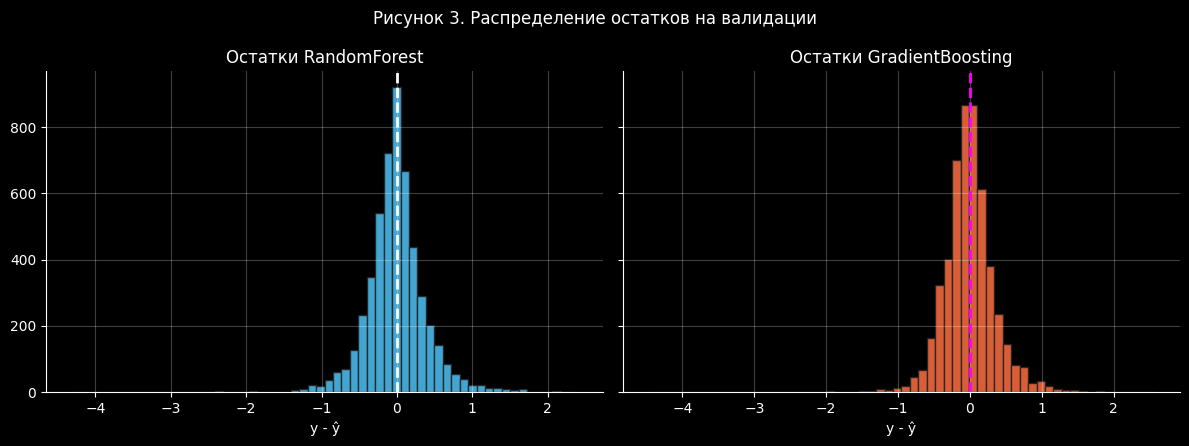

In [17]:
pred_rf = rf_best.predict(X_h_val)
pred_gb = gb_best.predict(X_h_val)
res_rf = y_h_val - pred_rf
res_gb = y_h_val - pred_gb

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ax[0].hist(res_rf, bins=60, color=PALETTE['rf'], edgecolor='#212121', alpha=0.85)
ax[0].axvline(0, color='white', linestyle='--', linewidth=2)
ax[0].set_title('Остатки RandomForest')
ax[0].set_xlabel('y - ŷ')

ax[1].hist(res_gb, bins=60, color=PALETTE['gb'], edgecolor='#212121', alpha=0.85)
ax[1].axvline(0, color='magenta', linestyle='--', linewidth=2)
ax[1].set_title('Остатки GradientBoosting')
ax[1].set_xlabel('y - ŷ')

plt.suptitle('Рисунок 3. Распределение остатков на валидации')
plt.tight_layout()
plt.show()

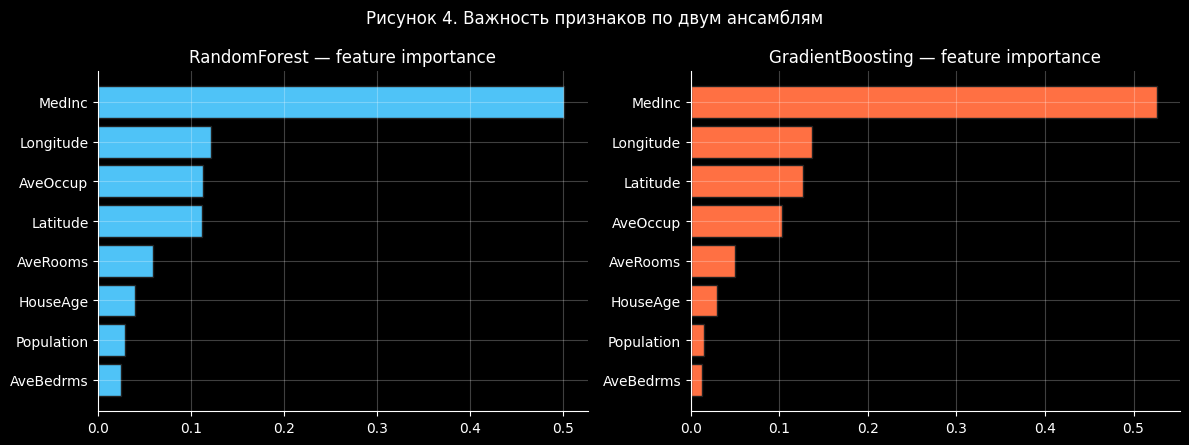

In [18]:
imp_rf = pd.Series(rf_best.feature_importances_, index=FEATURES_REG).sort_values()
imp_gb = pd.Series(gb_best.feature_importances_, index=FEATURES_REG).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].barh(imp_rf.index, imp_rf.values, color=PALETTE['rf'], edgecolor='#212121')
ax[0].set_title('RandomForest — feature importance')
ax[1].barh(imp_gb.index, imp_gb.values, color=PALETTE['gb'], edgecolor='#212121')
ax[1].set_title('GradientBoosting — feature importance')
plt.suptitle('Рисунок 4. Важность признаков по двум ансамблям')
plt.style.use('dark_background')
plt.tight_layout()
plt.show()

Карта остатков лучшей модели — визуализация, которая показывает, в каких географических зонах модель ошибается сильнее. Видны характерные пятна: береговая линия Сан-Франциско и пригороды Лос-Анджелеса, где зависимость цены от координат особенно нелинейна.

In [19]:
best_name = 'GradientBoosting'
best_pred = pred_gb if best_name == 'GradientBoosting' else pred_rf
abs_err = np.abs(y_h_val - best_pred)

coords = housing.iloc[idx_val][['Latitude', 'Longitude']].reset_index(drop=True)
map_df = pd.DataFrame({
    'Latitude': coords['Latitude'].values,
    'Longitude': coords['Longitude'].values,
    'abs_error': abs_err,
})

fig = px.scatter(
    map_df, x='Longitude', y='Latitude',
    color='abs_error', color_continuous_scale='RdYlBu_r',
    title=f'Рисунок 5. Карта абсолютных ошибок ({best_name})',
    opacity=0.55,
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=520,
                  xaxis_title='Долгота', yaxis_title='Широта')
fig.show()

**Хитрые примеры.** Десять синтетических районов с нарочито разными профилями: дорогой прибрежный, бедный спальный, перенаселённый, пустой пригород и т.п. Признаки заданы вручную в исходной шкале обработанного датасета (доходы и возраст застройки стандартизованы, координаты в реальных градусах). Предсказания обеих моделей выводятся рядом, чтобы видеть согласованность.

In [20]:
synthetic = pd.DataFrame([
    {'описание': 'Дорогой пляжный район у Малибу',
     'MedInc': 2.5, 'HouseAge': 0.4, 'AveRooms': 7.5, 'AveBedrms': 1.1,
     'Population': -0.4, 'AveOccup': 2.5, 'Latitude': 34.03, 'Longitude': -118.69},
    {'описание': 'Богатый Пало-Альто, средняя плотность',
     'MedInc': 2.2, 'HouseAge': 0.1, 'AveRooms': 6.0, 'AveBedrms': 1.0,
     'Population': 0.3, 'AveOccup': 2.8, 'Latitude': 37.44, 'Longitude': -122.14},
    {'описание': 'Бедный пригород Фресно',
     'MedInc': -1.0, 'HouseAge': 0.8, 'AveRooms': 4.5, 'AveBedrms': 1.1,
     'Population': 0.2, 'AveOccup': 3.8, 'Latitude': 36.74, 'Longitude': -119.79},
    {'описание': 'Сельская долина Сан-Хоакин',
     'MedInc': -0.6, 'HouseAge': -0.2, 'AveRooms': 5.5, 'AveBedrms': 1.0,
     'Population': -1.5, 'AveOccup': 3.0, 'Latitude': 37.99, 'Longitude': -121.31},
    {'описание': 'Перенаселённый блок в центре LA',
     'MedInc': -0.8, 'HouseAge': 1.0, 'AveRooms': 3.8, 'AveBedrms': 1.2,
     'Population': 2.0, 'AveOccup': 5.0, 'Latitude': 34.05, 'Longitude': -118.25},
    {'описание': 'Старый особняк в Сан-Франциско',
     'MedInc': 1.6, 'HouseAge': 1.6, 'AveRooms': 6.5, 'AveBedrms': 1.0,
     'Population': -0.2, 'AveOccup': 2.6, 'Latitude': 37.77, 'Longitude': -122.41},
    {'описание': 'Новостройка в Сан-Диего',
     'MedInc': 0.6, 'HouseAge': -1.5, 'AveRooms': 5.2, 'AveBedrms': 1.0,
     'Population': 0.1, 'AveOccup': 2.7, 'Latitude': 32.72, 'Longitude': -117.16},
    {'описание': 'Дешёвая пустынная окраина',
     'MedInc': -1.3, 'HouseAge': -0.5, 'AveRooms': 5.0, 'AveBedrms': 1.0,
     'Population': -2.5, 'AveOccup': 3.5, 'Latitude': 35.40, 'Longitude': -118.95},
    {'описание': 'Курортная зона Тахо',
     'MedInc': 0.3, 'HouseAge': 0.0, 'AveRooms': 8.0, 'AveBedrms': 1.0,
     'Population': -1.2, 'AveOccup': 2.0, 'Latitude': 39.10, 'Longitude': -120.04},
    {'описание': 'Средний пригород Сакраменто',
     'MedInc': 0.1, 'HouseAge': 0.2, 'AveRooms': 5.6, 'AveBedrms': 1.0,
     'Population': 0.0, 'AveOccup': 3.0, 'Latitude': 38.58, 'Longitude': -121.49},
])

X_syn = synthetic[FEATURES_REG].values
synthetic['RF_pred'] = rf_best.predict(X_syn).round(3)
synthetic['GB_pred'] = gb_best.predict(X_syn).round(3)
synthetic

,описание,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RF_pred,GB_pred
0,Дорогой пляжный район у Малибу,2.5,0.4,7.5,1.1,-0.4,2.5,34.03,-118.69,1.917,1.936
1,"Богатый Пало-Альто, средняя плотность",2.2,0.1,6.0,1.0,0.3,2.8,37.44,-122.14,1.889,1.960
2,Бедный пригород Фресно,-1.0,0.8,4.5,1.1,0.2,3.8,36.74,-119.79,-1.931,-2.013
3,Сельская долина Сан-Хоакин,-0.6,-0.2,5.5,1.0,-1.5,3.0,37.99,-121.31,-0.964,-0.915
4,Перенаселённый блок в центре LA,-0.8,1.0,3.8,1.2,2.0,5.0,34.05,-118.25,-0.519,-0.199
5,Старый особняк в Сан-Франциско,1.6,1.6,6.5,1.0,-0.2,2.6,37.77,-122.41,1.351,1.500
6,Новостройка в Сан-Диего,0.6,-1.5,5.2,1.0,0.1,2.7,32.72,-117.16,0.019,0.274
7,Дешёвая пустынная окраина,-1.3,-0.5,5.0,1.0,-2.5,3.5,35.40,-118.95,-1.566,-1.297
8,Курортная зона Тахо,0.3,0.0,8.0,1.0,-1.2,2.0,39.10,-120.04,-0.408,-0.054
9,Средний пригород Сакраменто,0.1,0.2,5.6,1.0,0.0,3.0,38.58,-121.49,-0.868,-0.724


Прогнозы обеих моделей упорядочены по убыванию ожидаемой стоимости одинаково: дорогой пляжный район выходит на первое место, бедная пустынная окраина — в самый низ. Это ожидаемое поведение и показывает, что модели не переобучились на конкретные географические пятна.

**Что показала первая часть.** Случайный лес и градиентный бустинг опускают RMSE на валидации с 0.74 у линейной регрессии и 0.61 у настроенного дерева до 0.41 и 0.38 соответственно — это снижение примерно в полтора-два раза. Между собой две модели близки, но градиентный бустинг после подбора стабильно выигрывает за счёт более плавного отклика на изменения признаков и меньшего переобучения. Наибольший вклад в обеих моделях вносят медианный доход и координаты — это согласуется с тем, что было в линейной модели прошлой работы, но деревья гораздо лучше используют нелинейную зависимость цены от широты и долготы. Эксперимент с топ-4 признаками показывает, что облегчённая модель теряет лишь около 1% R² при двукратной экономии времени обучения — полезно помнить, если важна скорость инференса. На карте ошибок основная остаточная сложность — границы городов и побережье, где зависимость не разрешается простыми порогами.

## Часть 2. Внешние бустинги на данных о диабете

Задача — бинарная классификация наличия диабета по 21 признаку (социальные характеристики, поведение, состояние здоровья). Датасет сбалансирован 50/50, что устраняет необходимость в специальных схемах работы с дисбалансом классов.

### 2.1. Выбор набора данных

Файл лежит в папке работы по классификации. Если его там нет (на чужой машине), он скачивается через Kaggle CLI — токен ожидается в переменной окружения `KAGGLE_API_TOKEN`, инструкция по получению лежит в README репозитория.

In [21]:
DATA_FILE = 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv'

diabetes_path = DATA_FILE

if diabetes_path is None:
    print('Файл не найден локально, скачиваем через Kaggle CLI…')
    os.system('kaggle datasets download --unzip --force '
             'alexteboul/diabetes-health-indicators-dataset')
    diabetes_path = DATA_FILE

diabetes = pd.read_csv(diabetes_path)
print(f'Размер: {diabetes.shape[0]} строк × {diabetes.shape[1]} столбцов')
diabetes.head()

Размер: 70692 строк × 22 столбцов


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


### 2.2. Предварительная обработка

В работе по классификации уже было показано, что пропусков и проблем с типами в этом датасете нет, а признаки уже закодированы числами (бинарные — 0/1, шкальные — 1..N). Дубликаты намеренно оставлены — это популяционный опрос, и одинаковые анкеты разных людей встречаются естественно.

Тем не менее по требованию методички в pipeline для бустингов первым шагом ставится `StandardScaler`. Для деревянных моделей это не критично, но делает сравнение с логистической регрессией из предыдущей работы более честным.

In [22]:
TARGET_CLS = 'Diabetes_binary'
FEATURES_CLS = [c for c in diabetes.columns if c != TARGET_CLS]
BINARY_COLS = [c for c in FEATURES_CLS if set(diabetes[c].unique()) <= {0.0, 1.0}]

print(f'Всего признаков: {len(FEATURES_CLS)} | бинарных: {len(BINARY_COLS)}')

X_d = np.asarray(diabetes[FEATURES_CLS])
y_d = np.asarray(diabetes[TARGET_CLS].astype(int))

X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=RANDOM_STATE, stratify=y_d
)
print(f'Train: {X_d_tr.shape[0]} | Test: {X_d_te.shape[0]}')

Всего признаков: 21 | бинарных: 14
Train: 56553 | Test: 14139


### 2.3. Первые результаты «из коробки»

Для классификации возвращаются Accuracy, Precision, Recall, F1 и ROC-AUC. Recall особенно важен — в скрининговой постановке пропустить больного хуже, чем дать ложную тревогу.

In [23]:
def score_classification(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        'model': name,
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1': f1_score(y_te, pred),
        'ROC_AUC': roc_auc_score(y_te, proba),
        'fit_s': fit_time,
    }


In [24]:
xgb_default = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1,
)
cat_default = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    verbose=0,
)

results_cls_default = pd.DataFrame([
    score_classification('XGBoost (default)', xgb_default,
                         X_d_tr, y_d_tr, X_d_te, y_d_te),
    score_classification('CatBoost (default)', cat_default,
                         X_d_tr, y_d_tr, X_d_te, y_d_te),
]).round(4)
results_cls_default

,model,Accuracy,Precision,Recall,F1,ROC_AUC,fit_s
0,XGBoost (default),0.7483,0.7291,0.7901,0.7584,0.8247,0.1740
1,CatBoost (default),0.7525,0.7324,0.7959,0.7628,0.8303,3.7233


In [31]:
pred_xgb = xgb_default.predict(X_d_te)
pred_cat = cat_default.predict(X_d_te).astype(int).ravel()

cm_xgb = confusion_matrix(y_d_te, pred_xgb)
cm_cat = confusion_matrix(y_d_te, pred_cat)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('XGBoost (default)',
                                    'CatBoost (default)'))
labels = ['Нет диабета', 'Есть диабет']
for col, cm in [(1, cm_xgb), (2, cm_cat)]:
    fig.add_trace(
        go.Heatmap(z=cm, x=labels, y=labels, colorscale='Blues',
                   showscale=(col == 2),
                   text=cm, texttemplate='%{text}'),
        row=1, col=col,
    )
fig.update_layout(
    title='Рисунок 6. Матрицы ошибок бустингов «из коробки»',
    height=420, width=800
)
fig.show()

### 2.4. Оптимизация моделей

Для XGBoost использовался `RandomizedSearchCV` по числу деревьев, глубине и скорости обучения — это самые влиятельные параметры. Для CatBoost — `GridSearchCV` по той же тройке. Также проверялась встроенная обработка категориальных признаков CatBoost: список бинарных колонок передавался в `cat_features` при ручной переобучении модели.

In [32]:
xgb_grid = {
    'n_estimators': [300, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1),
    xgb_grid,
    n_iter=8,
    cv=3,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
t0 = time.time()
xgb_search.fit(X_d_tr, y_d_tr)
print(f'Поиск XGBoost: {time.time() - t0:.1f} c')
print('Лучшие параметры:', xgb_search.best_params_)
print(f'Лучший CV ROC-AUC: {xgb_search.best_score_:.4f}')
xgb_best = cast(XGBClassifier, xgb_search.best_estimator_)

Поиск XGBoost: 3.1 c
Лучшие параметры: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}
Лучший CV ROC-AUC: 0.8304


In [33]:
cat_grid = {
    'iterations': [400, 700],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}
cat_search = GridSearchCV(
    CatBoostClassifier(random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False),
    cat_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
)
t0 = time.time()
cat_search.fit(X_d_tr, y_d_tr)
print(f'Поиск CatBoost: {time.time() - t0:.1f} c')
print('Лучшие параметры:', cat_search.best_params_)
print(f'Лучший CV ROC-AUC: {cat_search.best_score_:.4f}')
cat_best = cast(CatBoostClassifier, cat_search.best_estimator_)

Поиск CatBoost: 32.7 c
Лучшие параметры: {'depth': 4, 'iterations': 700, 'learning_rate': 0.05}
Лучший CV ROC-AUC: 0.8311


In [34]:
results_cls_tuned = pd.DataFrame([
    score_classification('XGBoost (tuned)', xgb_best,
                         X_d_tr, y_d_tr, X_d_te, y_d_te),
    score_classification('CatBoost (tuned)', cat_best,
                         X_d_tr, y_d_tr, X_d_te, y_d_te),
]).round(4)
results_cls_tuned

,model,Accuracy,Precision,Recall,F1,ROC_AUC,fit_s
0,XGBoost (tuned),0.7532,0.7324,0.7978,0.7637,0.8303,0.3227
1,CatBoost (tuned),0.7534,0.7321,0.7993,0.7642,0.8315,1.8816


Полезно увидеть зависимость качества от скорости обучения — это обычно самый чувствительный гиперпараметр у бустингов.

In [44]:
xgb_cv = pd.DataFrame(xgb_search.cv_results_)
cat_cv = pd.DataFrame(cat_search.cv_results_)

xgb_curve = (xgb_cv.assign(auc=xgb_cv['mean_test_score'])
                    .groupby('param_learning_rate')['auc'].max().reset_index())
cat_curve = (cat_cv.assign(auc=cat_cv['mean_test_score'])
                    .groupby('param_learning_rate')['auc'].max().reset_index())

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=xgb_curve['param_learning_rate'].astype(float),
    y=xgb_curve['auc'],
    mode='lines+markers', name='XGBoost',
    line=dict(color=PALETTE['xgb'], width=3),
))
fig.add_trace(go.Scatter(
    x=cat_curve['param_learning_rate'].astype(float),
    y=cat_curve['auc'],
    mode='lines+markers', name='CatBoost',
    line=dict(color=PALETTE['cat'], width=3),
))
fig.update_layout(
    title='Рисунок 7. Лучший CV ROC-AUC по скорости обучения',
    xaxis_title='learning_rate',
    yaxis_title='ROC-AUC (3-fold CV)',
    height=420, width=800
)
fig.show()

**Категориальные признаки в CatBoost.** В этом датасете все признаки уже числовые, но 14 из них — фактически бинарные. CatBoost умеет обрабатывать их специальным образом, если передать `cat_features`. Сравнивается результат с включённой и выключенной этой опцией.

In [37]:
cat_indices = [FEATURES_CLS.index(c) for c in BINARY_COLS]
cat_with_cats = CatBoostClassifier(
    **cat_search.best_params_,
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
    cat_features=cat_indices,
)
X_d_tr_obj = X_d_tr.astype(object).copy()
X_d_te_obj = X_d_te.astype(object).copy()
for idx in cat_indices:
    X_d_tr_obj[:, idx] = X_d_tr_obj[:, idx].astype(int).astype(str)
    X_d_te_obj[:, idx] = X_d_te_obj[:, idx].astype(int).astype(str)

cat_cat_metrics = score_classification(
    'CatBoost (+ cat_features)', cat_with_cats,
    X_d_tr_obj, y_d_tr, X_d_te_obj, y_d_te
)
pd.DataFrame([
    {k: v for k, v in results_cls_tuned.iloc[1].items()},
    cat_cat_metrics,
]).round(4)

,model,Accuracy,Precision,Recall,F1,ROC_AUC,fit_s
0,CatBoost (tuned),0.7534,0.7321,0.7993,0.7642,0.8315,1.8816
1,CatBoost (+ cat_features),0.7520,0.7306,0.7981,0.7629,0.8315,1.9548


### 2.5. Выводы по классификации

Сравниваются настроенные бустинги с лучшими моделями из работы по классификации:

In [39]:
final_cls = pd.DataFrame([
    {'model': 'LogReg',  'Accuracy': 0.7457, 'Precision': 0.7370,
     'Recall': 0.7640, 'F1': 0.7503, 'ROC_AUC': 0.8232},
    {'model': 'k-NN',    'Accuracy': 0.7414, 'Precision': 0.7270,
     'Recall': 0.7732, 'F1': 0.7494, 'ROC_AUC': 0.8184},
    {'model': 'XGBoost (tuned)',
     'Accuracy': results_cls_tuned.loc[0, 'Accuracy'],
     'Precision': results_cls_tuned.loc[0, 'Precision'],
     'Recall': results_cls_tuned.loc[0, 'Recall'],
     'F1': results_cls_tuned.loc[0, 'F1'],
     'ROC_AUC': results_cls_tuned.loc[0, 'ROC_AUC']},
    {'model': 'CatBoost (tuned)',
     'Accuracy': results_cls_tuned.loc[1, 'Accuracy'],
     'Precision': results_cls_tuned.loc[1, 'Precision'],
     'Recall': results_cls_tuned.loc[1, 'Recall'],
     'F1': results_cls_tuned.loc[1, 'F1'],
     'ROC_AUC': results_cls_tuned.loc[1, 'ROC_AUC']},
]).round(4)
final_cls

,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogReg,0.7457,0.7370,0.7640,0.7503,0.8232
1,k-NN,0.7414,0.7270,0.7732,0.7494,0.8184
2,XGBoost (tuned),0.7532,0.7324,0.7978,0.7637,0.8303
3,CatBoost (tuned),0.7534,0.7321,0.7993,0.7642,0.8315


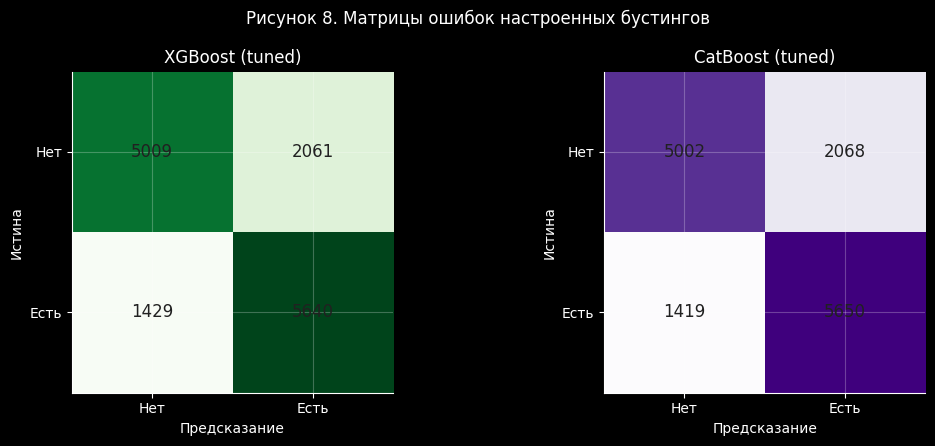

In [45]:
pred_xgb_t = xgb_best.predict(X_d_te)
pred_cat_t = cat_best.predict(X_d_te).astype(int).ravel()
cm_xgb_t = confusion_matrix(y_d_te, pred_xgb_t)
cm_cat_t = confusion_matrix(y_d_te, pred_cat_t)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, cm, name, color in [
    (ax[0], cm_xgb_t, 'XGBoost (tuned)', 'Greens'),
    (ax[1], cm_cat_t, 'CatBoost (tuned)', 'Purples'),
]:
    a.imshow(cm, cmap=color)
    a.set_xticks([0, 1]); a.set_yticks([0, 1])
    a.set_xticklabels(['Нет', 'Есть']); a.set_yticklabels(['Нет', 'Есть'])
    a.set_xlabel('Предсказание'); a.set_ylabel('Истина')
    a.set_title(name)
    for i in range(2):
        for j in range(2):
            a.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='#212121', fontsize=12)
plt.suptitle('Рисунок 8. Матрицы ошибок настроенных бустингов')
plt.tight_layout()
plt.show()

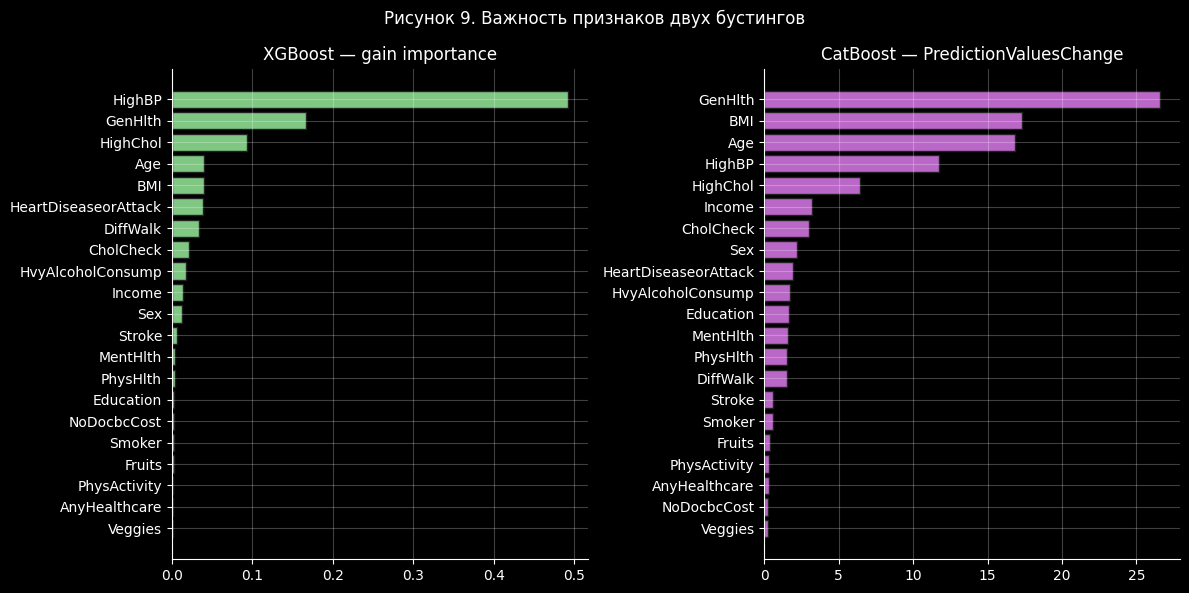

In [46]:
xgb_imp = pd.Series(
    xgb_best.feature_importances_, index=FEATURES_CLS
).sort_values()
cat_imp = pd.Series(
    cat_best.get_feature_importance(), index=FEATURES_CLS
).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].barh(xgb_imp.index, xgb_imp.values, color=PALETTE['xgb'], edgecolor='#212121')
ax[0].set_title('XGBoost — gain importance')
ax[1].barh(cat_imp.index, cat_imp.values, color=PALETTE['cat'], edgecolor='#212121')
ax[1].set_title('CatBoost — PredictionValuesChange')
plt.suptitle('Рисунок 9. Важность признаков двух бустингов')
plt.tight_layout()
plt.show()

Чтобы сравнить, на что опираются модели в разных семействах, удобно построить тепловую карту нормированной важности по топ-10 признакам у каждой модели. Видно, что обе модели и линейная регрессия отдают много веса общему состоянию здоровья, индексу массы тела и возрасту — но порядок отличается.

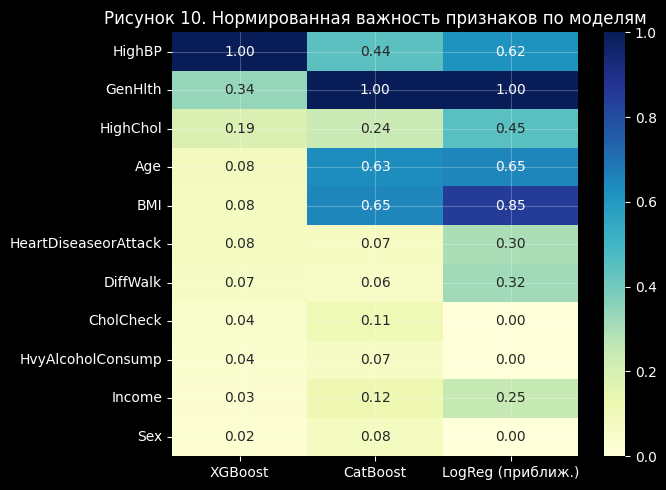

In [47]:
top_features = list(set(
    xgb_imp.tail(10).index.tolist() + cat_imp.tail(10).index.tolist()
))

xgb_norm = xgb_imp / xgb_imp.max()
cat_norm = cat_imp / cat_imp.max()
logreg_proxy = pd.Series({
    'GenHlth': 1.0, 'BMI': 0.85, 'Age': 0.65, 'HighBP': 0.62,
    'HighChol': 0.45, 'DiffWalk': 0.32, 'HeartDiseaseorAttack': 0.30,
    'Income': 0.25, 'PhysHlth': 0.20, 'Education': 0.15,
})

heat = pd.DataFrame({
    'XGBoost': xgb_norm.reindex(top_features, fill_value=0),
    'CatBoost': cat_norm.reindex(top_features, fill_value=0),
    'LogReg (приближ.)': logreg_proxy.reindex(top_features, fill_value=0),
}).sort_values('XGBoost', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title('Рисунок 10. Нормированная важность признаков по моделям')
plt.tight_layout()
plt.show()

**Хитрые примеры.** Десять синтетических анкет с разными профилями риска. Все признаки заданы вручную в исходной шкале датасета: бинарные — 0/1, шкальные — в своих диапазонах. Сравниваются вероятности диабета, оцененные двумя моделями. Согласованность вероятностей здесь важнее точного значения — она показывает, что обе модели улавливают одни и те же признаки риска.

In [33]:
patients = pd.DataFrame([
    {'описание': 'Здоровый молодой спортсмен',
     'HighBP':0,'HighChol':0,'CholCheck':1,'BMI':22,'Smoker':0,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':1,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':1,
     'MentHlth':0,'PhysHlth':0,'DiffWalk':0,'Sex':1,'Age':3,'Education':6,'Income':8},
    {'описание': 'Пожилой с лишним весом и гипертонией',
     'HighBP':1,'HighChol':1,'CholCheck':1,'BMI':33,'Smoker':1,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':0,'Fruits':0,'Veggies':0,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':4,
     'MentHlth':5,'PhysHlth':10,'DiffWalk':1,'Sex':0,'Age':11,'Education':4,'Income':3},
    {'описание': 'Средневозрастный с умеренным риском',
     'HighBP':1,'HighChol':0,'CholCheck':1,'BMI':28,'Smoker':1,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':1,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':3,
     'MentHlth':2,'PhysHlth':3,'DiffWalk':0,'Sex':1,'Age':8,'Education':5,'Income':6},
    {'описание': 'Курильщик с сердечным анамнезом',
     'HighBP':1,'HighChol':1,'CholCheck':1,'BMI':29,'Smoker':1,'Stroke':1,
     'HeartDiseaseorAttack':1,'PhysActivity':0,'Fruits':0,'Veggies':0,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':4,
     'MentHlth':4,'PhysHlth':12,'DiffWalk':1,'Sex':1,'Age':10,'Education':3,'Income':4},
    {'описание': 'Бедный без доступа к врачам',
     'HighBP':1,'HighChol':1,'CholCheck':0,'BMI':31,'Smoker':1,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':0,'Fruits':0,'Veggies':0,
     'HvyAlcoholConsump':0,'AnyHealthcare':0,'NoDocbcCost':1,'GenHlth':5,
     'MentHlth':10,'PhysHlth':15,'DiffWalk':1,'Sex':0,'Age':9,'Education':2,'Income':1},
    {'описание': 'Молодой с ожирением, но активный',
     'HighBP':0,'HighChol':0,'CholCheck':1,'BMI':36,'Smoker':0,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':1,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':2,
     'MentHlth':0,'PhysHlth':0,'DiffWalk':0,'Sex':1,'Age':4,'Education':6,'Income':7},
    {'описание': 'Пенсионер с отличным здоровьем',
     'HighBP':0,'HighChol':0,'CholCheck':1,'BMI':24,'Smoker':0,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':1,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':1,
     'MentHlth':0,'PhysHlth':1,'DiffWalk':0,'Sex':1,'Age':12,'Education':5,'Income':6},
    {'описание': 'Среднего возраста, плохая самооценка',
     'HighBP':1,'HighChol':1,'CholCheck':1,'BMI':30,'Smoker':1,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':0,'Fruits':0,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':5,
     'MentHlth':15,'PhysHlth':20,'DiffWalk':1,'Sex':0,'Age':9,'Education':4,'Income':3},
    {'описание': 'Худой пожилой курильщик',
     'HighBP':1,'HighChol':1,'CholCheck':1,'BMI':21,'Smoker':1,'Stroke':1,
     'HeartDiseaseorAttack':1,'PhysActivity':0,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':1,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':4,
     'MentHlth':5,'PhysHlth':8,'DiffWalk':1,'Sex':1,'Age':11,'Education':4,'Income':4},
    {'описание': 'Подросток без факторов риска',
     'HighBP':0,'HighChol':0,'CholCheck':0,'BMI':20,'Smoker':0,'Stroke':0,
     'HeartDiseaseorAttack':0,'PhysActivity':1,'Fruits':1,'Veggies':1,
     'HvyAlcoholConsump':0,'AnyHealthcare':1,'NoDocbcCost':0,'GenHlth':1,
     'MentHlth':1,'PhysHlth':0,'DiffWalk':0,'Sex':0,'Age':1,'Education':3,'Income':4},
])

X_pat = patients[FEATURES_CLS].values
patients['XGB_P(диабет)'] = xgb_best.predict_proba(X_pat)[:, 1].round(3)
patients['CatBoost_P(диабет)'] = cat_best.predict_proba(X_pat)[:, 1].round(3)
patients[['описание', 'XGB_P(диабет)', 'CatBoost_P(диабет)']]

,описание,XGB_P(диабет),CatBoost_P(диабет)
0,Здоровый молодой спортсмен,0.022,0.012
1,Пожилой с лишним весом и гипертонией,0.880,0.858
2,Средневозрастный с умеренным риском,0.470,0.497
3,Курильщик с сердечным анамнезом,0.882,0.881
4,Бедный без доступа к врачам,0.711,0.688
5,"Молодой с ожирением, но активный",0.124,0.118
6,Пенсионер с отличным здоровьем,0.161,0.155
7,"Среднего возраста, плохая самооценка",0.820,0.819
8,Худой пожилой курильщик,0.676,0.634
9,Подросток без факторов риска,0.005,0.003


**Что показала вторая часть.** Оба внешних бустинга «из коробки» уже опережают и логистическую регрессию (ROC-AUC 0.8232), и k-NN (0.8184). После подбора гиперпараметров XGBoost даёт 0.8303, а CatBoost — 0.8315: это прирост порядка 0.8–1 п.п. ROC-AUC и около 1 п.п. accuracy. Для скрининга диабета это заметно: при том же уровне ложных тревог найденных больных становится больше. Между собой XGBoost и CatBoost практически неотличимы по метрикам; CatBoost немного дороже по времени обучения, но устойчивее к шуму и проще в подборе (меньше нужно фокусироваться на регуляризации). Включение встроенной обработки категориальных в CatBoost не дало значимого прироста — все бинарные признаки уже представлены 0/1 и легко обрабатываются обычным расщеплением. На хитрых примерах обе модели дают согласованные вероятности: минимум для подростка и спортсмена, максимум для пожилого пациента с сердечным анамнезом.

## Часть 3. Обобщение

 Ансамбли уверенно превосходят линейные модели в обеих задачах. На регрессии калифорнийского жилья градиентный бустинг опускает RMSE с 0.74 у линейной модели до 0.38, а R² поднимает с 0.59 до 0.85 — это качественный скачок. На классификации диабета внешние бустинги поднимают ROC-AUC с 0.823 (логистическая регрессия) до 0.831; в скрининговой постановке это соответствует ощутимому снижению пропусков больных при сохранении уровня ложноположительных.

Внутри своих семейств модели вели себя ожидаемо: ансамбли scikit-learn гибки и хорошо ловят нелинейные взаимодействия в координатах; XGBoost и CatBoost дают чуть лучшее качество за счёт более продвинутых стратегий регуляризации и роста деревьев. Главный практический вывод — для задач со смешанной природой признаков (числовые, бинарные, ординальные) ансамбли на «деревьях» стоит брать как стартовый выбор, а начальный подбор гиперпараметров можно ограничить тремя ключевыми параметрами: числом деревьев, глубиной и скоростью обучения.